# Brainomni Benchmark

## EEG Dataset - Info

The dataset to be used is [DS006576]("https://eegdash.org/api/dataset/eegdash.dataset.DS006576.html"). Original article: [The Role of Rapid Eye Movement Sleep in Neural Differentiation of Memories in the Hippocampus]("https://direct.mit.edu/jocn/article/38/1/126/131951/The-Role-of-Rapid-Eye-Movement-Sleep-in-Neural")

- Hardware - BioSemi ActiveTwo System (active electrodes of Ag/AgCl)
- Channels: 64 scalp channels, and:
    - 2 EOG channels (LOC, ROC)
    - 2 EMG channels (bipolar derivative)
    - 2 ECG channels
    - 2 mastoids (reference channels)
- Sampling rate: 512 Hz

No estadiamento:

- Pré-processado para 256Hz
- Filtros do estadiamento: Passa-faixa de 0.3 a 35 Hz com filtro notch de 60 Hz (para EEG/EOG); passa-faixa de 10 a 70 Hz (para EMG).

Participantes e grupos:

The participants are 69 healthy adults, divided in 23 per group:
1. REM: Snap (~90 min) with NREM + REM sleep
2. NREM: Fast snap (~50 min) with only NREM sleep
3. Wake: Safe 90 min vigil (listening to podcasts)

## EEG Dataset - Download

In [1]:
# Importa utilitarios de sistema e manipulacao de diretorios
import os
from pathlib import Path

# Importa bibliotecas para plotagem grafica, MNE para dados eletrofisiologicos e arrays numericos
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import time

# Importa o modulo eegdash e o construtor de datasets
import eegdash
from eegdash import EEGDashDataset
# Importa estilos visuais padronizados do EEGDash
from eegdash.viz import style_figure, use_eegdash_style

# Dataset
from eegdash.dataset import DS006576

## Preprocessing
from braindecode.preprocessing import (
    EEGPrep,
    Preprocessor,
    create_fixed_length_windows,
    preprocess,
)

from pyprep.find_noisy_channels import NoisyChannels
from mne.preprocessing import ICA, compute_proj_eog, compute_proj_ecg

# Extra
import re

# Forca o backend matplotlib para o navegador do MNE para permitir captura estatica das figuras
mne.viz.set_browser_backend("matplotlib")

# Aplica o tema visual do EEGDash
use_eegdash_style()

# Define o caminho do diretorio de cache persistente
cache_dir = os.environ.get("EEGDASH_CACHE_DIR", str(Path.home() / ".eegdash_cache"))
print(f"eegdash {eegdash.__version__}; cache_dir={cache_dir}")

# Define dataset
dataset = DS006576(cache_dir="./data") # Preload = True downloads the entire dataset.

# Triggers EEG download
# for record in dataset.datasets:
#     try:
#         _ = record.raw
#     except Exception as e:
#         print(f"Skipping failed subject: {e}")

dataset

/home/arielalves/Área de trabalho/undergrad-research-eeg-fm/Models-Benchmarking/.brainomni-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/arielalves/Área de trabalho/undergrad-research-eeg-fm/Models-Benchmarking/.brainomni-venv/lib/python3.12/site-packages/braindecode/models/eegpt.py:497: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage("standard_1020")
/home/arielalves/Área de trabalho/undergrad-research-eeg-fm/Models-Benchmarking/.brainomni-venv/lib/python3.12/site-packages/braindecode/models/eegpt.py:1452: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = make_standard_montage("standard_1020")


Using matplotlib as 2D backend.
eegdash 0.9.1; cache_dir=/home/arielalves/.eegdash_cache


[09/17/26 13:19:19] WARNING  File not found on S3, skipping:                                      downloader.py:286
                             s3://openneuro.org/ds006576/sub-137/eeg/sub-137_task-rest_eeg.dat                     

<BaseConcatDataset | 67 EEGDashRaw(s) | 215106560 total samples>
  Sfreq*: 512.0 Hz
  Channels*: 73 (2 ECG, 64 EEG, 2 EMG, 2 EOG, 2 MISC, 1 STIM)
  Ch. names*: A1_Fp1, A2_AF7, A3_AF3, A4_F1, A5_F3, A6_F5, A7_F7, A8_FT7, A9_FC5, A10_FC3, ... (+63 more)
  Duration*: 6429.0 s
  (* from first recording)
  Description: 67 recordings × 8 columns [subject, task, sex, group, session, run, age, gender]

## EEG Dataset - First Recording Analysis

### 1. General info

In [2]:
record = dataset.datasets[0]
record.description

subject     137
task       rest
sex           f
group       REM
session     NaN
run         NaN
age         NaN
gender      NaN
dtype: str

In [3]:
raw = record.raw.load_data().copy() # Generate a copy

Reading 0 ... 3291647  =      0.000 ...  6428.998 secs...


### 2. Channels Voltage measurement and calibration factor

In [4]:
raw.info['chs'][0]['unit']

107 (FIFF_UNIT_V)

All the channel values are measured in Volts (SI). To obtain $\mu V$, it is necessary to multiply by $10^{-6}$

### 3. Channels names and classification

In [5]:
for ch_name, ch_type in zip(raw.ch_names, raw.get_channel_types()):
    print(f"{ch_name:10s} -> {ch_type}")

A1_Fp1     -> eeg
A2_AF7     -> eeg
A3_AF3     -> eeg
A4_F1      -> eeg
A5_F3      -> eeg
A6_F5      -> eeg
A7_F7      -> eeg
A8_FT7     -> eeg
A9_FC5     -> eeg
A10_FC3    -> eeg
A11_FC1    -> eeg
A12_C1     -> eeg
A13_C3     -> eeg
A14_C5     -> eeg
A15_T7     -> eeg
A16_TP7    -> eeg
A17_CP5    -> eeg
A18_CP3    -> eeg
A19_CP1    -> eeg
A20_P1     -> eeg
A21_P3     -> eeg
A22_P5     -> eeg
A23_P7     -> eeg
A24_P9     -> eeg
A25_PO7    -> eeg
A26_PO3    -> eeg
A27_O1     -> eeg
A28_Iz     -> eeg
A29_Oz     -> eeg
A30_POz    -> eeg
A31_Pz     -> eeg
A32_CPz    -> eeg
B1_Fpz     -> eeg
B2_Fp2     -> eeg
B3_AF8     -> eeg
B4_AF4     -> eeg
B5_AFz     -> eeg
B6_Fz      -> eeg
B7_F2      -> eeg
B8_F4      -> eeg
B9_F6      -> eeg
B10_F8     -> eeg
B11_FT8    -> eeg
B12_FC6    -> eeg
B13_FC4    -> eeg
B14_FC2    -> eeg
B15_FCz    -> eeg
B16_Cz     -> eeg
B17_C2     -> eeg
B18_C4     -> eeg
B19_C6     -> eeg
B20_T8     -> eeg
B21_TP8    -> eeg
B22_CP6    -> eeg
B23_CP4    -> eeg
B24_CP2   

- `A1_Fp1` a `B32_O2` (64 canais) - Canais de EEG de escalpo. 
- `A1`,`A2` - Referências de mastoides (Mastoide Esquerda / Mastoide Direita)
- `LOC`,`ROC` - EOG
- `EMG1`,`EMG2` - EMG
- `ECG1`,`ECG2` - ECG
- `Status` - Canal digital de sincronização/triggers de eventos e controle do hardware BioSemi

## EEG Dataset - Pre-processing First Recording EEG

The EEG Raw don't have any processing. It is bad to use the raw data as a foundation model input, since it can contain noise or bad channels.

### 1. Rename the channels to standard names (extracting string after '_')

In [6]:
rename_dict = {ch: ch.split('_')[1] for ch in raw.ch_names if '_' in ch}
raw.rename_channels(rename_dict)

raw.ch_names

['Fp1',
 'AF7',
 'AF3',
 'F1',
 'F3',
 'F5',
 'F7',
 'FT7',
 'FC5',
 'FC3',
 'FC1',
 'C1',
 'C3',
 'C5',
 'T7',
 'TP7',
 'CP5',
 'CP3',
 'CP1',
 'P1',
 'P3',
 'P5',
 'P7',
 'P9',
 'PO7',
 'PO3',
 'O1',
 'Iz',
 'Oz',
 'POz',
 'Pz',
 'CPz',
 'Fpz',
 'Fp2',
 'AF8',
 'AF4',
 'AFz',
 'Fz',
 'F2',
 'F4',
 'F6',
 'F8',
 'FT8',
 'FC6',
 'FC4',
 'FC2',
 'FCz',
 'Cz',
 'C2',
 'C4',
 'C6',
 'T8',
 'TP8',
 'CP6',
 'CP4',
 'CP2',
 'P2',
 'P4',
 'P6',
 'P8',
 'P10',
 'PO8',
 'PO4',
 'O2',
 'A1',
 'A2',
 'LOC',
 'ROC',
 'EMG1',
 'EMG2',
 'ECG1',
 'ECG2',
 'Status']

### 2. Applying standard montage

The standard montage associates spatial 3D coordinates in each electrode according to its name.

In [7]:
#raw.set_channel_types({ch: 'eeg' for ch in raw.ch_names}) # Not necessary: already set
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, match_case=False, on_missing='ignore')

/tmp/ipykernel_3671790/4087013890.py:2: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage('standard_1020')
/tmp/ipykernel_3671790/4087013890.py:3: RuntimeWarning: Not setting positions of 2 misc channels found in montage:
['A1', 'A2']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage, match_case=False, on_missing='ignore')


<RawBrainVision | sub-137_task-rest_eeg.eeg, 73 x 3291648 (6429.0 s), ~1.79 GiB, data loaded>

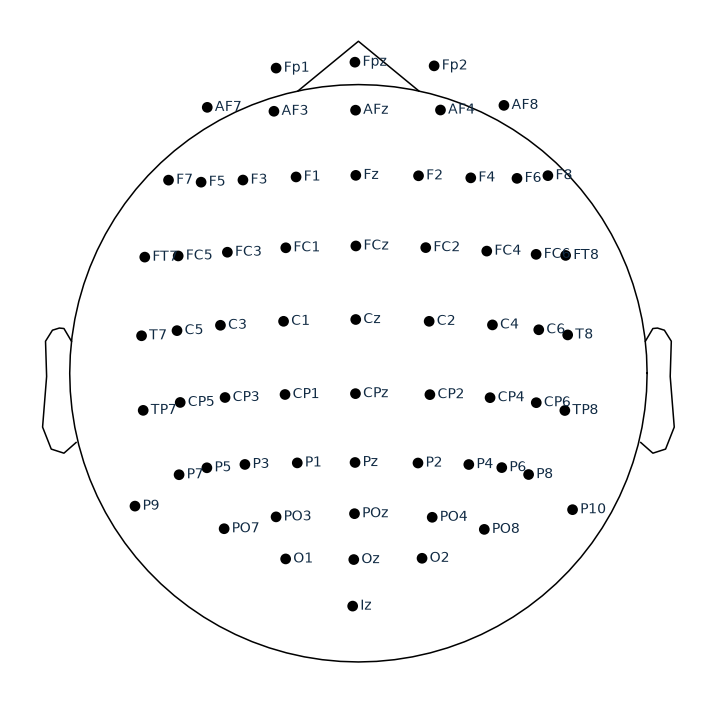

In [8]:
raw.plot_sensors(show_names=True, show=False);

Comparing with 10-10 system (10-20 system with high resolution), it is possible to see that the channels are correct. Image font: [10-20 system (EEG) - Wikipedia](https://en.wikipedia.org/wiki/10%E2%80%9320_system_%28EEG%29).

![EEG_10-10 System](https://thumb.wikimedia.org/wikipedia/commons/thumb/f/fb/EEG_10-10_system_with_additional_information.svg/960px-EEG_10-10_system_with_additional_information.svg.png?utm_source=en.wikipedia.org&utm_campaign=imageinfo&utm_content=thumbnail)

Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


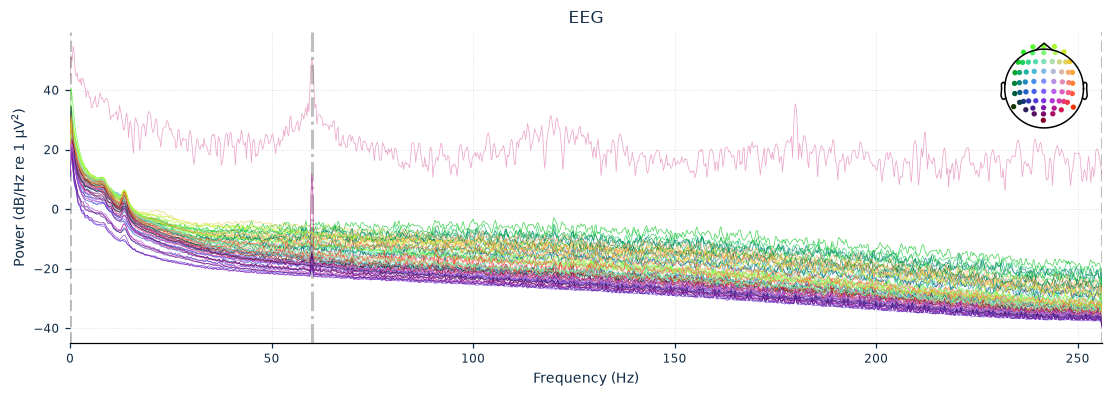

In [9]:
raw.compute_psd().plot(show=False);

Effective window size : 4.000 (s)


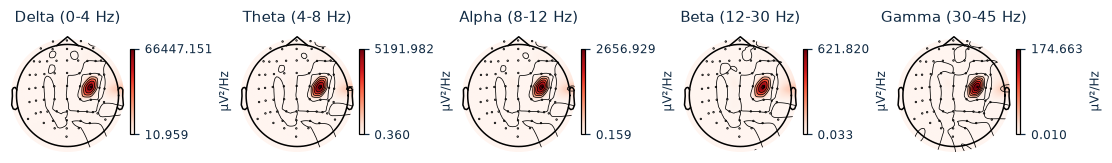

In [10]:
raw.compute_psd().plot_topomap();

### 3. Checking bad channels (automatic)

It is posible to see that `C4` is diverging: it is a bad channel, probably caused by equipment with placement errors, or hardware errors.

It is possible to use `NoisyChannels` to detect bad channels. Using `ransac` is expensive, but efficient for bad channels detection. It needs a montage first.

In [ ]:
nc = NoisyChannels(raw, random_state=42)
nc.find_all_bads(ransac=True) # Set RANSAC = True if do you have a good computer.
raw.info['bads'] = nc.get_bads()

Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 1691 samples (3.303 s)



[09/17/26 13:19:54] INFO     Executing RANSAC, this may take a while, so be patient...                ransac.py:205

 13%|█▎        |  : 169/1285 [00:20<02:13,    8.36it/s]

In [ ]:
raw.info['bads']

['P2', 'PO3', 'P1', 'POz', 'PO4', 'C4', 'P3', 'Pz']

RANSAC determined C4 as bad channel, and found other bad channels.

### 4. Fixing bad channels

Let's reconstruct the channels. `interpolate_bads()` mathematically reconstructs the signals of bad/missing channels using the recorder signals of their surrounding, clean neighbor channels. It uses the channels marked as bad in `raw.info['bads']`.

In [ ]:
raw.interpolate_bads(reset_bads=True)

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 96.3 mm
Computing interpolation matrix from 56 sensor positions
Interpolating 8 sensors


<RawBrainVision | sub-137_task-rest_eeg.eeg, 73 x 3291648 (6429.0 s), ~1.79 GiB, data loaded>

In [ ]:
psd = raw.compute_psd()

Effective window size : 4.000 (s)


Plotting power spectral density (dB=True).


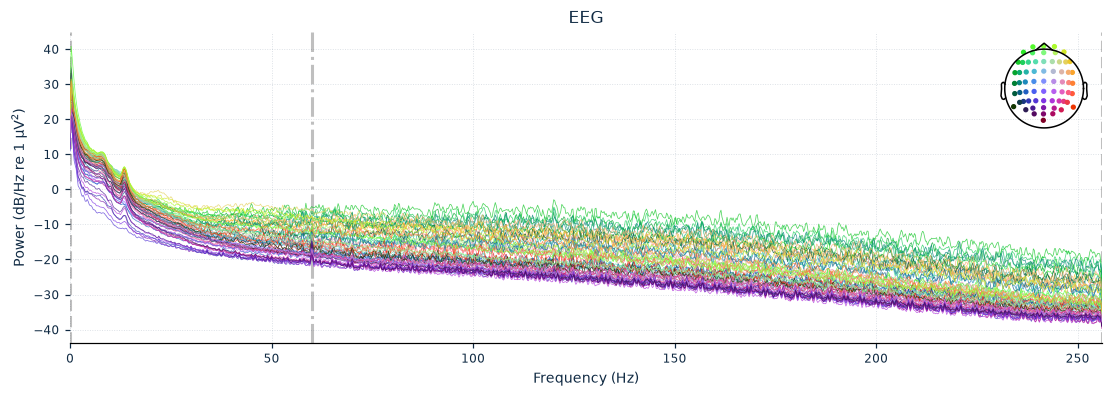

In [ ]:
psd.plot(show=False);

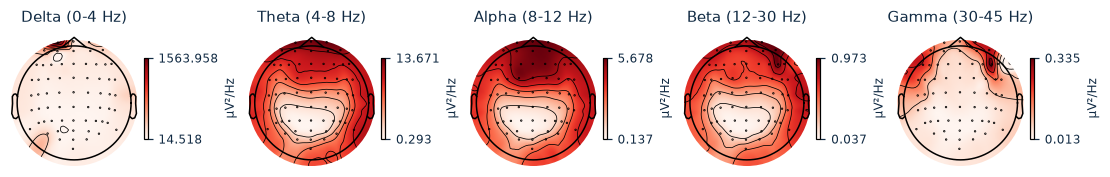

In [ ]:
psd.plot_topomap(show=False);

In [ ]:
# raw.plot(
#     duration=5.0,                  # Window length to display (in seconds)
#     n_channels=15,                 # Number of channels shown per screen
#     scalings={'eeg': 80e-6},       # Auto-scale amplitude ('auto' or dict like {'eeg': 40e-6})
#     clipping=None,                 # Prevent trace clipping outside channel lanes
#     show_options=True,             # Open the settings/control panel
#     block=True                     # Block script execution until window is closed (useful in standalone scripts)
# );

### 5. Removing EOG/ECG interference

Note that in the topomap, the frontal sensors have a dense diference of potential. It is caused by blinks.

In [ ]:
# Filtered copy for stable ICA decomposition (ICA performs poorly if trained on low-frequency drifts (< 1.0Hz)
raw_ica = raw.copy().filter(l_freq=1.0, h_freq=None, fir_design="firwin", verbose="ERROR")
# ICA model
ica = ICA(n_components=15, random_state=42, method="fastica")
# Train ICA model with raw data
ica.fit(raw_ica)

bads = []
# Find ocular artifacts using LOC and ROC
eog_indices, _ = ica.find_bads_eog(raw) # Defaults to looking for 'eog' type channels
bads.extend(eog_indices)
# Find cardiac artifacts using ECG
ecg_indices, _ = ica.find_bads_ecg(raw) # Defaults to looking for 'ecg' type channels
bads.extend(ecg_indices)
# Mark components to remove
ica.exclude = list(set(bads))
print(f"[Eliminate artifacts] ICA removed components: {ica.exclude}")
# Remove components and reconstruct EEG signal. Applies to original raw.
ica.apply(raw)

Use rng= instead of random_state= in new code
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 65.6s.
Using EOG channels: LOC, ROC
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband 

/tmp/ipykernel_3649133/776627576.py:13: RuntimeWarning: More than one ECG channel found. Using only ECG1.
  ecg_indices, _ = ica.find_bads_ecg(raw) # Defaults to looking for 'ecg' type channels
/tmp/ipykernel_3649133/776627576.py:13: RuntimeWarning: More than one ECG channel found. Using only ECG1.
  ecg_indices, _ = ica.find_bads_ecg(raw) # Defaults to looking for 'ecg' type channels


Number of ECG events detected : 6722 (average pulse 62.734484367708816 / min.)
Not setting metadata
6722 matching events found
No baseline correction applied
Using data from preloaded Raw for 6722 events and 513 original time points ...
1 bad epochs dropped
Using threshold: 0.30 for CTPS ECG detection
[Eliminate artifacts] ICA removed components: []
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 0 ICA components
    Projecting back using 64 PCA components


<RawBrainVision | sub-137_task-rest_eeg.eeg, 73 x 3291648 (6429.0 s), ~1.79 GiB, data loaded>

In [ ]:
raw.compute_psd()
raw.plot_psd_topomap(show=False);

### 6. A1/A2 reference

Calculates $\frac{V_{\text{A}_1}(t)+V_{\text{A}_2}(t)}{2}$ at each time point and subtracts it at every channel. (better than average reference for sleep staging)

In [ ]:
raw.set_channel_types({'A1': 'eeg', 'A2': 'eeg'})
raw.set_eeg_reference(ref_channels=['A1', 'A2'])
raw.drop_channels(['A1', 'A2'])

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.


<RawBrainVision | sub-137_task-rest_eeg.eeg, 64 x 3291648 (6429.0 s), ~1.57 GiB, data loaded>

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


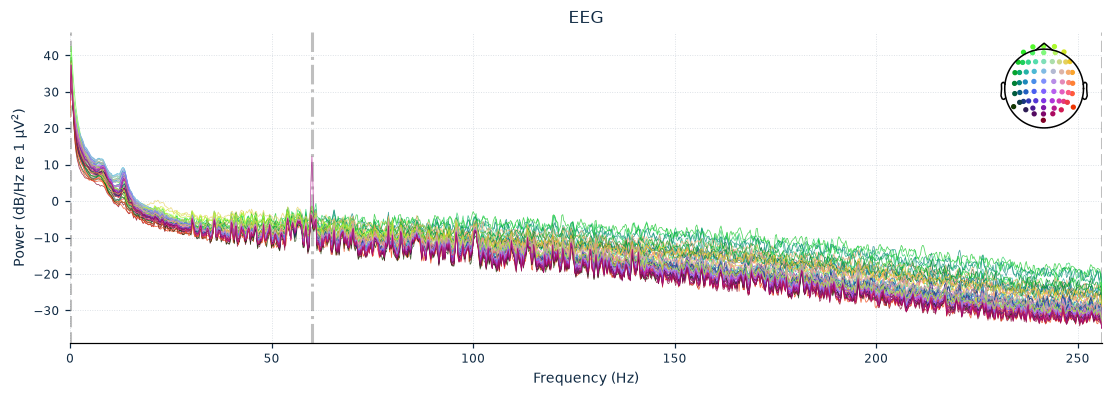

In [ ]:
raw.plot_psd();

### 7. Band-Pass Filter

Eliminates noise and (like 50-60 Hz electrical network noise) and frequencies that don't matter. What matters for EEG is only delta, theta, alpha, beta, gamma waves. So a good range to limit our frequencies is between 0.5 Hz and 40 Hz.

In [ ]:
L_FREQ = 0.5
H_FREQ = 40

raw.filter(
    l_freq=L_FREQ,       # low-pass
    h_freq=H_FREQ,       # high-pass
    method="fir",
    fir_design="firwin", 
    phase="zero",        # Don't change peak positions in the time (phase delay)
    verbose=False,
)

<RawBrainVision | sub-137_task-rest_eeg.eeg, 64 x 3291648 (6429.0 s), ~1.57 GiB, data loaded>

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


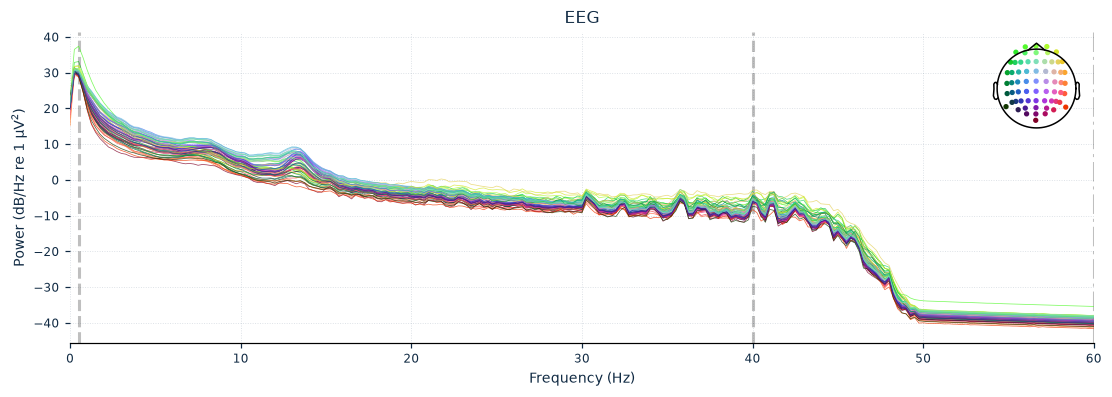

In [ ]:
raw.plot_psd(fmin=0, fmax=60);

### 8. Resampling to 200 Hz

Only frequencies 0-40 Hz are been evaluated. Applying a 200 Hz resampling, it saves 60% of space and the maximum possible measuring frequency is 100 Hz (60 Hz above necessary). It is a huge space/processing saving.

In [ ]:
TARGET_SFREQ = 200
raw.resample(TARGET_SFREQ, verbose=False)

<RawBrainVision | sub-137_task-rest_eeg.eeg, 64 x 1285800 (6429.0 s), ~627.9 MiB, data loaded>

## EEG Dataset - Investigating all the dataset

In [ ]:
subjects_channels = []

for idx, record in enumerate(dataset.datasets):
    #raw = record.raw.load_data().copy() # Stores in RAM and generate a copy
    try:
        raw = record.raw # Reads from disk
    except (FileNotFoundError, Exception) as e:
         print(f"Skipping subject {record.description["subject"]}") # If .eeg doesn't exist, skip
         continue

    # Rename channels
    rename_dict = {ch: ch.split('_')[1] for ch in raw.ch_names if '_' in ch}
    raw.rename_channels(rename_dict)

    # Set montage 10-20
    raw.set_channel_types({ch: 'eeg' for ch in raw.ch_names})
    montage = mne.channels.make_standard_montage('colin27_1020')
    raw.set_montage(montage, match_case=False, on_missing='ignore')

    subjects_channels.append(f"Subject {record.description["subject"]} channels: {raw.ch_names}\n")

    # Plot psd and psd topomap. If it already exists, skip.
    os.makedirs("./subjects-analysis", exist_ok=True) # Ensure that the folder already exists
    os.makedirs("./subjects-analysis/before", exist_ok=True) # Ensure that the folder already exists

    fig1_path = f"./subjects-analysis/before/psd_{record.description["subject"]}_before.png"
    fig2_path = f"./subjects-analysis/before/psd_topomap_{record.description["subject"]}_before.png"
    if (os.path.exists(fig1_path) and os.path.exists(fig2_path)): continue

    psd = raw.compute_psd(verbose=False)
    fig1 = psd.plot_topomap(show=False);
    fig2 = psd.plot(show=False);

    fig1.suptitle(f"Subject {record.description["subject"]} ({record.description["group"]}) PSD")
    fig2.suptitle(f"Subject {record.description["subject"]} ({record.description["group"]}) PSD Topomap")
    fig2.savefig(fig1_path, dpi=300, bbox_inches="tight")
    fig1.savefig(fig2_path, dpi=300, bbox_inches="tight")

with open("./subjects-analysis/subjects-channels.txt", "w") as f:
        for line in subjects_channels:
            f.write(line)
    

Each EEG recording is unique, and it may contain errors. By analysing the PSD, it is possible to see weird channels at EEG recordings.

### Good EEG recordings identification

Subjects 107,115,119,120,122,125,127,133,139,141,142,147,148,149,150,152,153,155,156,158,162,165,166,168,169,172,176,177,182,184,186

### Bad channels identification

Bad channels have visible noise or are split apart by 20 to 40 dB across other channel frequencies.

|Recording | Num. of Bad Channels|
|----------|----------|
|110| 3|
|112| 3|
|117|4|
|132|2|
|134|4|
|135|1|
|137|1|
|143|1|
|144|3|
|145|2|
|146|2|
|151|1|
|164|1|
|179|2|
|181|2|
|185|1|
|187|1|
|188|1|

### Bad recordings identification

Criteries for recording discarding:

- **Global Comb-Filter / Serrated Pattern (1)** - Hardware Clock or Grounding Failure. It looks like periodic ripples recurring every few HErtz across the entire frequency range.
- **Flat High-Frequency Floor (2)** - Amplifier Saturation / Quantization Noise. The curve stops its natural $1/f$ downward roll-off and flattens out completely into a horizontal line above 20–30 Hz at high amplitude (e.g., above 10–20 dB).
- **Massive Channel Dispersion Across the Whole Spectrum (3)** - Instead of a tight bundle of channels rolling off together, a large fraction of the channels (e.g., >20–30%) are split apart by 20 to 40 dB across both low and high frequencies. If only 1-3 isolated channels diverge, the session is keep.

|Recording | Problem |
|----------|----------|
|104|1|
|105|1|
|106|1|
|107|1|
|109|1|
|111|1|
|114|1|
|116|3|
|140|3|
|159|1|
|160|3|
|161|3|
|174|1|
|175|1|
|180|1|

### Missing channels identification

There are no subjects with as significative number of missing channels. Analysing the generated "subject-channels.txt", it is possible to assume every EEG recording as a complete recording.

### Deleting bad recordings from dataset

In [ ]:
# List of subject IDs to drop
BAD_SUBJECTS = {"104", "105", "106", "107", "109", "111", "114", "116", "140", "160", "161", "174", "175", "180"}

# Filter out bad subjects in-place
dataset.datasets = [
    record for record in dataset.datasets 
    if str(record.description["subject"]) not in BAD_SUBJECTS
]

dataset

<BaseConcatDataset | 53 EEGDashRaw(s) | 171672576 total samples>
  Sfreq*: 512.0 Hz
  Channels*: 73 (2 ECG, 64 EEG, 2 EMG, 2 EOG, 2 MISC, 1 STIM)
  Ch. names*: A1_Fp1, A2_AF7, A3_AF3, A4_F1, A5_F3, A6_F5, A7_F7, A8_FT7, A9_FC5, A10_FC3, ... (+63 more)
  Duration*: 6429.0 s
  (* from first recording)
  Description: 53 recordings × 8 columns [subject, task, sex, group, session, run, age, gender]

# EEG Dataset - Treating all recordings

It is possible to detect bad (EXPLAIN AUTO_DETECT_BADS FORMULA)

In [ ]:
# Custom function: if channel diverge from others, mark it as bad.
# def auto_detect_bads(raw, z_thresh=6.0):
#     data = raw.get_data(picks="eeg")
#     stds = np.std(data, axis=1) # Standard deviation
#     median_std = np.median(stds) # Average standard deviation
#     mad = np.median(np.abs(stds - median_std)) or 1e-6
#     modified_z = 0.6745 * (stds - median_std) / mad

#     eeg_names = [raw.ch_names[i] for i in mne.pick_types(raw.info, eeg=True)]
#     bads = [ch for ch, z in zip(eeg_names, modified_z) if z > z_thresh]

#     raw.info["bads"] = list(set(raw.info["bads"] + bads))
#     return raw

# Custom function: Detect bad channels
def auto_detect_bads(raw, ransac=True):
    nc = NoisyChannels(raw, random_state=42)
    nc.find_all_bads(ransac=ransac) # Set RANSAC = True if do you have a good computer.
    raw.info['bads'] = nc.get_bads()
    return raw

# Custom function: Eliminate artifacts caused by eyes/heart.
def eliminate_artifacts(raw, ica=True, eog=True, ecg=True):
    if(not eog and not ecg):
        print("[Eliminate artifacts] Bad arguments. Skipping.")
        return

    # Verify existence of EOG/ECG channels
    has_eog = len(mne.pick_types(raw.info, meg=False, eeg=False, eog=True, ecg=False)) > 0
    has_ecg = len(mne.pick_types(raw.info, meg=False, eeg=False, eog=False, ecg=True)) > 0

    # If EOG/ECG channels doesn't exists, pick channels next to eyes
    if has_eog:
        ch_eog = None
    else:
        ch_next = ['Fp1', 'FP1', 'Fp2', 'FP2', 'AF3', 'AF4']
        for ch in ch_next:
            if ch in raw.ch_names:
                ch_eog = ch
                break

    # ICA has a big computational cost
    if(ica):
        # Filtered copy for stable ICA decomposition (ICA performs poorly if trained on low-frequency drifts (< 1.0Hz)
        raw_ica = raw.copy().filter(l_freq=1.0, h_freq=None, fir_design="firwin", verbose="ERROR")
        # ICA model
        ica = ICA(n_components=15, random_state=42, method="fastica")
        # Train ICA model with raw data
        ica.fit(raw_ica)

        bads = []
        # Find ocular artifacts using LOC and ROC
        if(eog and (has_eog or ch_eog)): 
            eog_indices, _ = ica.find_bads_eog(raw, ch_name=ch_eog)
            bads.extend(eog_indices)
        # Find cardiac artifacts using ECG
        if(ecg and has_ecg): 
            ecg_indices, _ = ica.find_bads_ecg(raw, ch_name=None) # If ch_name = None, MNE checks raw for any channels marked as type
            bads.extend(ecg_indices)
        # Mark components to remove
        ica.exclude = list(set(bads))
        print(f"[Eliminate artifacts] ICA removed components: {ica.exclude}")
        # Remove components and reconstruct EEG signal. Applies to original raw.
        ica.apply(raw)

    # SSP is faster than ICA
    else:
        if eog and (has_eog or ch_eog):
            projs_eog, _ = compute_proj_eog(raw, ch_name=ch_eog, n_grad=0, n_mag=0, n_eeg=1, verbose="ERROR")
            raw.add_proj(projs_eog)

        if ecg and has_ecg:
            projs_ecg, _ = compute_proj_ecg(raw, ch_name=None, n_grad=0, n_mag=0, n_eeg=1, verbose="ERROR")
            raw.add_proj(projs_ecg)

        raw.apply_proj()
    
    # Drop aux channels (optimize memory use)
    aux_channels = ['LOC', 'ROC', 'ECG1', 'ECG2', 'EMG1', 'EMG2', 'Status']
    raw.drop_channels([ch for ch in aux_channels if ch in raw.ch_names])
    return raw

# Custom function: Interpolate bad channels if any were detected
def interpolate_bads_if_any(raw):
    if raw.info["bads"]:
        raw.interpolate_bads(reset_bads=False) # Feedback of interpolated channels
        # This info will be used to decide which records exclude/mantain
    return raw

# Custom function: set A1/A2 reference
def define_reference(raw):
    raw.set_channel_types({'A1': 'eeg', 'A2': 'eeg'})
    raw.set_eeg_reference(ref_channels=['A1', 'A2'])
    raw.drop_channels(['A1', 'A2'])
    return raw

# Custom function: drop non-EEG channels
def drop_non_eeg(raw):
    aux_channels = ['LOC', 'ROC', 'EMG1', 'EMG2', 'ECG1', 'ECG2', 'Status']
    channels_to_drop = [ch for ch in aux_channels if ch in raw.ch_names]
    raw.drop_channels(channels_to_drop)
    return raw

# Custom function: rename EEG channels
def rename_channels(raw):
    rename_dict = {ch: ch.split('_')[1] for ch in raw.ch_names if '_' in ch}
    raw.rename_channels(rename_dict)
    return raw

A interpolação espacial baseia-se na premissa de que a maioria dos canais é limpa e serve de âncora. Nos Pacientes 1, 3 e 4, o ruído rítmico afeta a quase totalidade dos canais. Interpolar canais ruins a partir de vizinhos igualmente contaminados apenas espalha o artefato.

Aplicar o filtro Notch / Passa-faixa antes da detecção: Remover offsets lentos e ruído de linha primeiro permite que o MAD/Z-score identifique apenas canais com variância discrepante real.

Descartar gravações inviáveis: Pacientes como o 4 (e possivelmente o 1 e 3 se o filtro não limpar a faixa <40 Hz) devem ser excluídos da modelagem via critério de rejeição global (ex.: se $>20\%$ dos canais forem marcados como ruins, rejeitar a sessão).

In [ ]:
L_FREQ = 1
H_FREQ = 40
TARGET_SFREQ = 200

# Process only few recordings (because i don't have a strong PC)
dataset.datasets = dataset.datasets[0:5]

# Process dataset in-memory (RAM)
preprocess(
    dataset,
    [
        # Note: if apply_on_array=False, passes raw object. If not, passes raw underlying NumPy array.
        
        # 1. Rename channels
        Preprocessor(rename_channels, apply_on_array=False),
        # 2. Set montage
        Preprocessor("set_montage", montage="standard_1020", on_missing="ignore"),
        # 3. Detect bad channels
        Preprocessor(auto_detect_bads, ransac=True, apply_on_array=False),
        # 4. Interpolate bad channels
        Preprocessor(interpolate_bads_if_any, apply_on_array=False),
        # 5. Eliminate EOG/ECG artifacts
        Preprocessor(eliminate_artifacts, ica=True, apply_on_array=False),
        # 6. Set A1/A2 reference
        Preprocessor(define_reference, apply_on_array=False),
        # 7. Band-pass filter
        Preprocessor(
            "filter",
            l_freq=L_FREQ,
            h_freq=H_FREQ,
            method="fir",
            fir_design="firwin",
        ),
        # Downsampling
        Preprocessor("resample", sfreq=TARGET_SFREQ),
    ],
)

Reading 0 ... 3291647  =      0.000 ...  6428.998 secs...


/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/Models-Benchmarking/.brainomni-venv/lib/python3.12/site-packages/braindecode/preprocessing/preprocess.py:78: UserWarning: apply_on_array can only be True if fn is a callable function. Automatically correcting to apply_on_array=False.
  warn(
/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/Models-Benchmarking/.brainomni-venv/lib/python3.12/site-packages/braindecode/preprocessing/preprocess.py:120: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  return getattr(raw_or_epochs, fn)(**kwargs)
/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/Models-Benchmarking/.brainomni-venv/lib/python3.12/site-packages/braindecode/preprocessing/preprocess.py:120: RuntimeWarning: Not setting positions of 2 misc channels found in montage:
['A1', 'A2']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_monta

Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 1691 samples (3.303 s)



[09/16/26 23:59:11] INFO     Executing RANSAC, this may take a while, so be patient...                ]8;id=15081596;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/Models-Benchmarking/.brainomni-venv/lib/python3.12/site-packages/pyprep/ransac.py\ransac.py]8;;\:]8;id=15081597;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/Models-Benchmarking/.brainomni-venv/lib/python3.12/site-packages/pyprep/ransac.py#205\205]8;;\

100%|██████████|  : 1285/1285 [40:02<00:00,    1.87s/it]


...

/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/Models-Benchmarking/.brainomni-venv/lib/python3.12/site-packages/braindecode/preprocessing/preprocess.py:120: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  return getattr(raw_or_epochs, fn)(**kwargs)


Reading 0 ... 3843583  =      0.000 ...  7506.998 secs...


/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/Models-Benchmarking/.brainomni-venv/lib/python3.12/site-packages/braindecode/preprocessing/preprocess.py:120: RuntimeWarning: Not setting positions of 2 misc channels found in montage:
['A1', 'A2']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  return getattr(raw_or_epochs, fn)(**kwargs)


Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 1691 samples (3.303 s)



: 

In [ ]:
for record in dataset.datasets:
    if(record.raw.info["bads"]): print(f"{record.description["subject"]} Bad Channels (Auto): {record.raw.info["bads"]}")

137 Bad Channels (Auto): ['POz', 'P1', 'PO3', 'P2', 'PO4', 'P3', 'Pz', 'C4']
108 Bad Channels (Auto): ['Pz']
106 Bad Channels (Auto): ['AF7', 'Fp1', 'Fpz', 'C3', 'T7', 'P5', 'Fp2', 'FT7', 'FT8', 'AF8']
139 Bad Channels (Auto): ['Fz', 'POz', 'P4']
107 Bad Channels (Auto): ['CP3', 'CPz', 'CP2', 'P2', 'O1', 'C1', 'C5']


Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


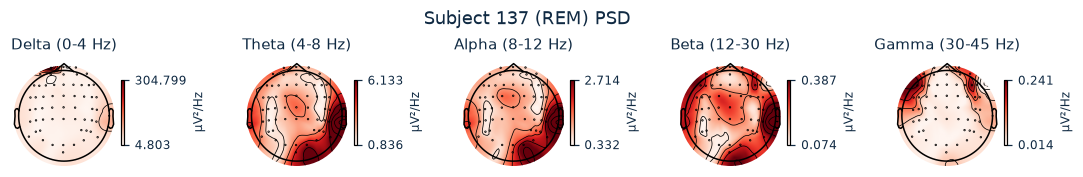

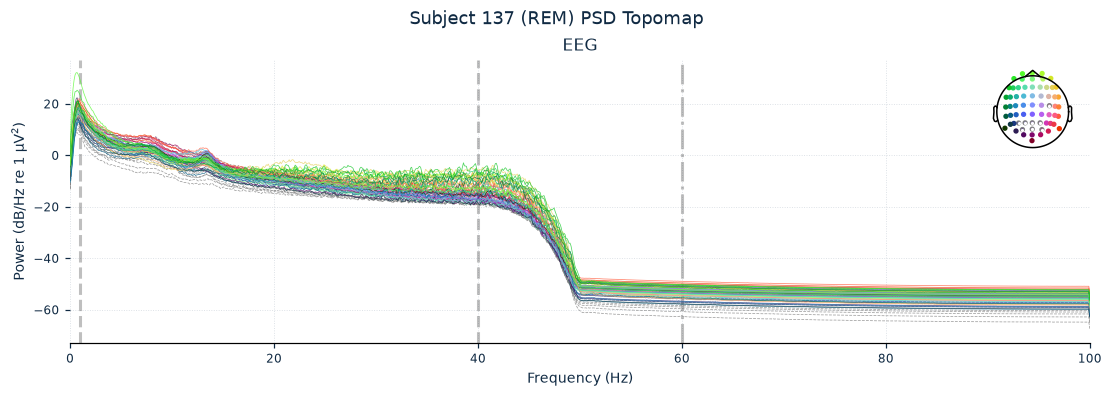

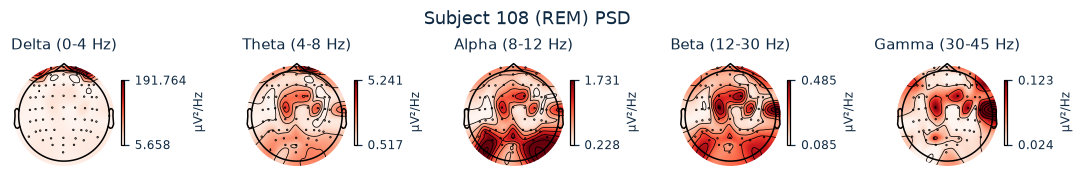

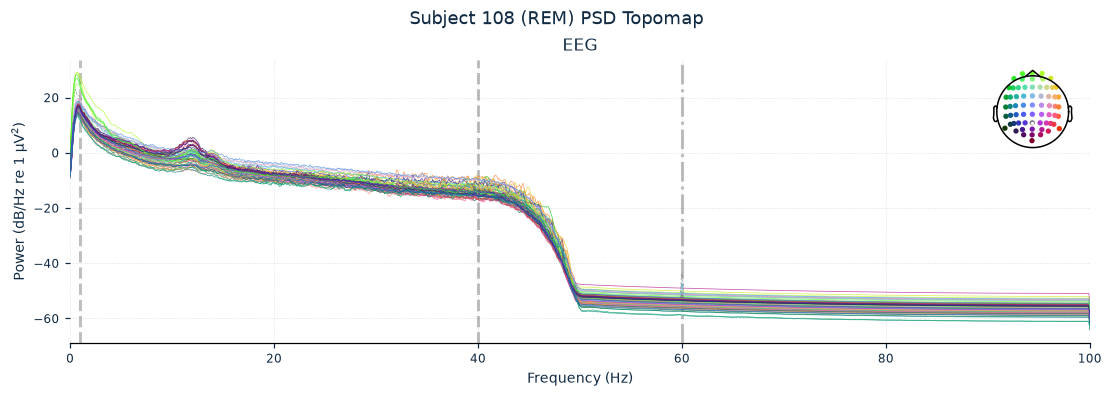

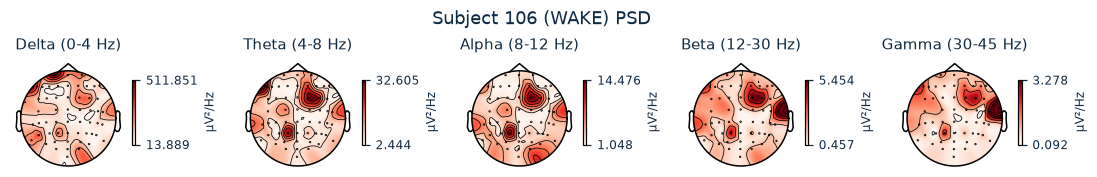

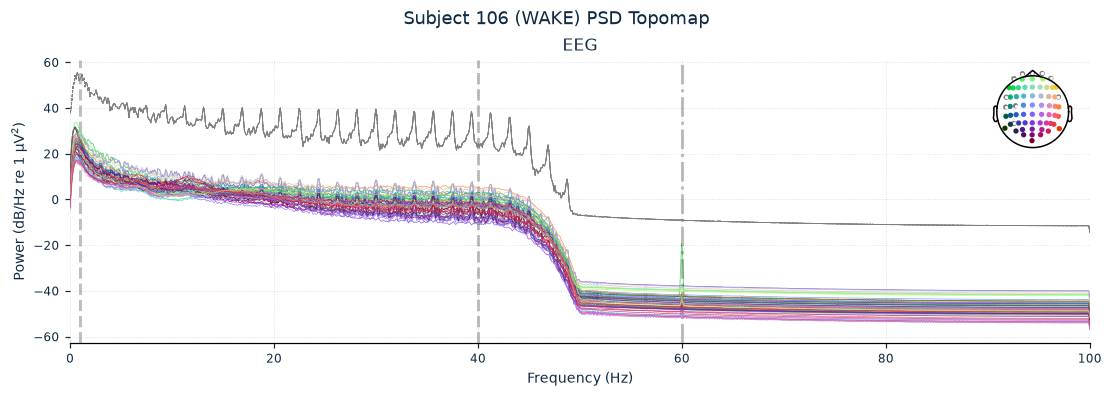

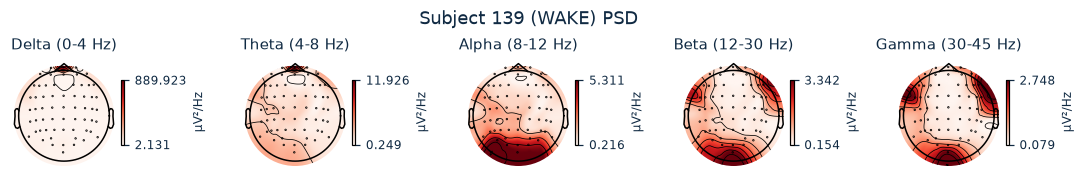

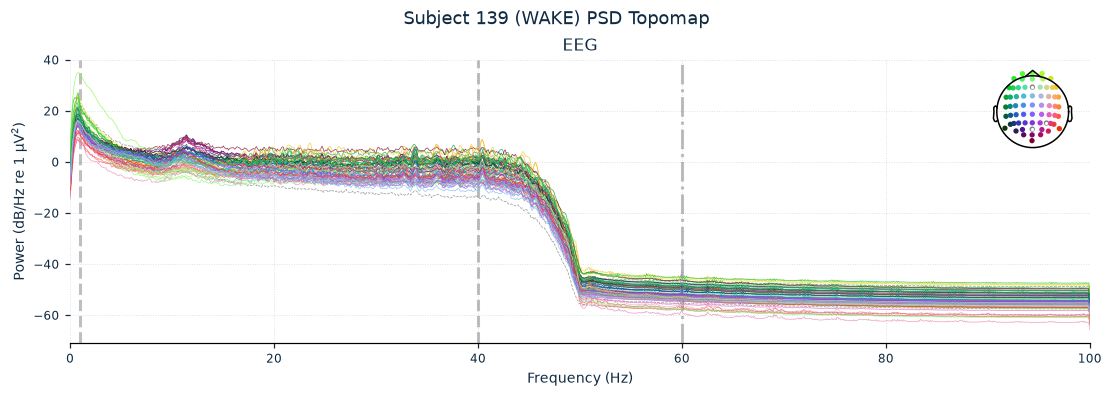

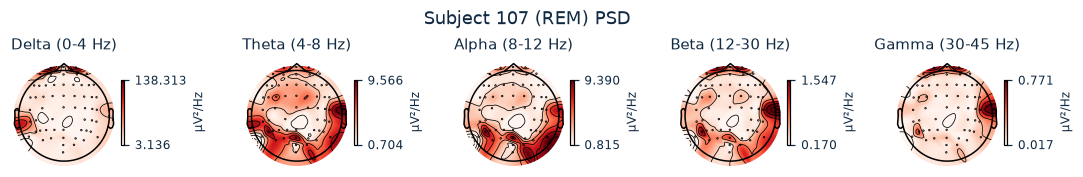

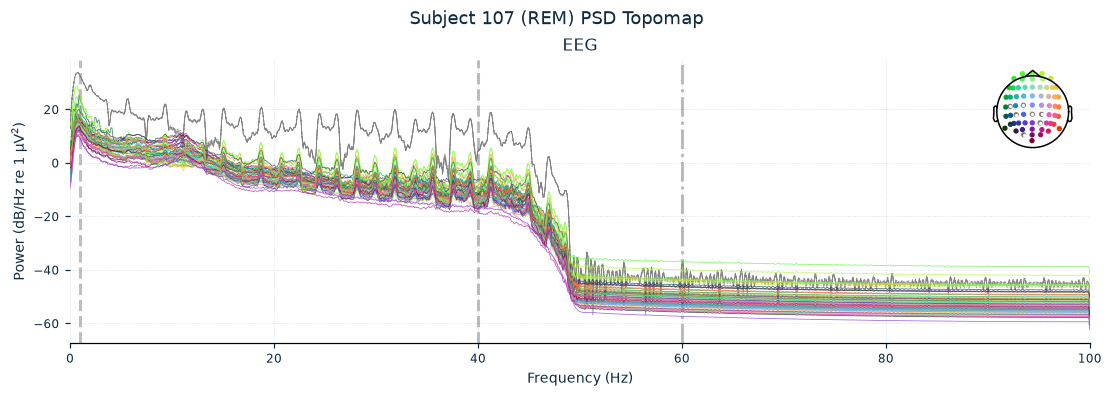

In [ ]:
os.makedirs("./subjects-analysis", exist_ok=True) # Ensure that the folder already exists
os.makedirs("./subjects-analysis/after", exist_ok=True) # Ensure that the folder already exists

for idx, record in enumerate(dataset.datasets):
    fig1_path = f"./subjects-analysis/after/psd_{record.description["subject"]}_after.png"
    fig2_path = f"./subjects-analysis/after/psd_topomap_{record.description["subject"]}_after.png"

    psd = record.raw.compute_psd(verbose=False)
    fig1 = psd.plot_topomap(show=False);
    fig2 = psd.plot(show=False);

    fig1.suptitle(f"Subject {record.description["subject"]} ({record.description["group"]}) PSD")
    fig2.suptitle(f"Subject {record.description["subject"]} ({record.description["group"]}) PSD Topomap")
    fig2.savefig(fig1_path, dpi=300, bbox_inches="tight")
    fig1.savefig(fig2_path, dpi=300, bbox_inches="tight")

## EEG Dataset: Save pre-processed recordings

In [ ]:
from braindecode.datasets import BaseConcatDataset

# Drop bad recordings
valid_recordings = []
for record in dataset.datasets:
    drop_tolerance = 0.15
    ch_bads = len(record.raw.info["bads"])
    ch_total = len(record.raw.ch_names)
    if(ch_bads > int(ch_total * drop_tolerance)):
        print(f"Bad recording of subject {record.description["subject"]}: {ch_bads} bad channels of {ch_total} channels. Dropping.")
        continue
    else:
        valid_recordings.append(record)
    
clean_concat_ds = BaseConcatDataset(valid_recordings)
# Define frequencia de amostragem e tamanho da janela em segundos
SFREQ, WIN_S = 200, 4
# Cria janelas de comprimento fixo de 200 amostras com 0% de sobreposicao
windows = create_fixed_length_windows(
    clean_concat_ds,
    start_offset_samples=0,
    stop_offset_samples=None,
    window_size_samples=WIN_S * SFREQ,
    window_stride_samples=WIN_S * SFREQ,
    drop_last_window=True,
    preload=True,
)
n_windows = len(windows)
sample_shape = windows[0][0].shape
n_channels, window_samples = int(sample_shape[0]), int(sample_shape[1])

# Cria diretorio temporario seguro para testes de persistencia
os.makedirs("./pre-processed-eeg", exist_ok=True) # Ensure that the folder already exists
# Mede o tempo de gravacao do conjunto janelado em formato FIF
windows.save("./pre-processed-eeg/", overwrite=True)

# Extra Notes

## Average Reference

Whether to apply an average reference depends on your **recording hardware**, **channel count**, and **analysis goal**:

---

### When You MUST Apply It

* **BioSemi systems:** BioSemi hardware records "reference-free" using active CMS/DRL circuits. If you do not apply an average reference (or a mastoid reference), your data will contain arbitrary DC offsets and floating potentials.
* **High-density montages (64+ channels):** When you have dense spatial coverage covering most of the head, the sum of electrical potentials approaches zero ($\sum V \approx 0$). Average reference provides the closest approximation to an inactive, neutral reference.
* **Source localization / EEG inverse problems:** Standard forward models (e.g., boundary element models) assume an average reference.

---

### When You Should NOT Apply It

* **Low-channel setups (< 32 channels, e.g., 8–16):** With few channels, the spatial sampling is insufficient to cover the whole head. Strong localized activity (like an occipital alpha rhythm or an eye blink) will contaminate all other channels because its value gets subtracted across the whole array.
* **Sleep scoring / Polysomnography standard:** Clinical sleep scoring (AASM standard) requires contralateral or linked **mastoid references** (`M1`/`M2` or `A1`/`A2`), not average reference.
* **Noisy/uncleaned channels present:** If bad channels have not been identified and excluded, their high-amplitude artifacts will be injected into every clean channel during the averaging step.

---

### Practical Rule of Thumb

* **For 64-channel cognitive/ML workflows:** Clean or interpolate bad channels first, then apply `raw.set_eeg_reference('average', projection=False)`.
* **For sleep staging:** Reference to the mastoids (`ref_channels=['A1', 'A2']`) to match classical polysomnography standards.

## Makoto's preprocessing pipeline

[Makoto's preprocessing pipeline](https://eeglab.ucsd.edu/wiki/Makoto%27s_preprocessing_pipeline)